In [4]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/FIRMS/fire_archive_SV-C2_806010.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Shape:", df.shape)

Dataset loaded successfully
Rows: 1739550
Columns: 15
Shape: (1739550, 15)


In [5]:
print("COLUMN NAMES")
print("=" * 50)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

COLUMN NAMES
 1. latitude
 2. longitude
 3. brightness
 4. scan
 5. track
 6. acq_date
 7. acq_time
 8. satellite
 9. instrument
10. confidence
11. version
12. bright_t31
13. frp
14. daynight
15. type


In [6]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,11.60804,79.38103,330.42,0.34,0.56,2023-09-15,726,SNPP,SNPP,n,2,291.44,1.57,D,0
1,9.83476,79.06087,367.00,0.38,0.59,2023-09-15,726,SNPP,SNPP,h,2,291.72,10.62,D,0
2,9.65347,78.72186,338.66,0.40,0.60,2023-09-15,726,SNPP,SNPP,n,2,292.06,4.74,D,0
3,9.83540,79.06435,345.56,0.38,0.59,2023-09-15,726,SNPP,SNPP,n,2,291.12,11.50,D,0
4,12.68536,79.35842,343.66,0.32,0.55,2023-09-15,726,SNPP,SNPP,n,2,290.17,3.61,D,0


In [7]:
df.tail()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
1739545,13.02426,79.42697,315.46,0.40,0.45,2026-06-30,2004,SNPP,SNPP,n,2,288.02,3.36,N,0
1739546,13.02015,79.42636,306.70,0.40,0.45,2026-06-30,2004,SNPP,SNPP,n,2,287.67,3.09,N,0
1739547,24.68910,73.00157,305.33,0.40,0.60,2026-06-30,2141,SNPP,SNPP,n,2,291.57,3.62,N,2
1739548,24.68903,73.00307,304.65,0.40,0.60,2026-06-30,2141,SNPP,SNPP,n,2,291.68,3.30,N,2
1739549,22.41736,69.03963,308.74,0.51,0.49,2026-06-30,2142,SNPP,SNPP,n,2,292.23,3.65,N,2


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1739550 entries, 0 to 1739549
Data columns (total 15 columns):
 #   Column      Dtype  
---  ------      -----  
 0   latitude    float64
 1   longitude   float64
 2   brightness  float64
 3   scan        float64
 4   track       float64
 5   acq_date    str    
 6   acq_time    int64  
 7   satellite   str    
 8   instrument  str    
 9   confidence  str    
 10  version     int64  
 11  bright_t31  float64
 12  frp         float64
 13  daynight    str    
 14  type        int64  
dtypes: float64(7), int64(3), str(5)
memory usage: 199.1 MB


In [9]:
missing = df.isna().sum()

print("MISSING VALUES")
print("=" * 50)
print(missing)

MISSING VALUES
latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
type          0
dtype: int64


In [10]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary

,missing_count,missing_percent
latitude,0,0.0
longitude,0,0.0
brightness,0,0.0
scan,0,0.0
track,0,0.0
acq_date,0,0.0
acq_time,0,0.0
satellite,0,0.0
instrument,0,0.0
confidence,0,0.0


In [11]:
duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,1739550.0,22.491448,4.546633,8.07930,19.605563,22.495875,25.205860,34.68580
longitude,1739550.0,80.850404,5.313125,68.49146,77.043000,80.079870,83.805325,97.11166
brightness,1739550.0,331.430252,17.012348,208.00000,317.000000,335.370000,342.400000,367.00000
scan,1739550.0,0.451820,0.080344,0.32000,0.390000,0.430000,0.500000,0.80000
track,1739550.0,0.467159,0.108594,0.36000,0.370000,0.430000,0.550000,0.78000
acq_time,1739550.0,1127.244666,567.269216,536.00000,739.000000,811.000000,1938.000000,2208.00000
version,1739550.0,2.000000,0.000000,2.00000,2.000000,2.000000,2.000000,2.00000
bright_t31,1739550.0,301.403606,9.861240,150.00000,294.010000,301.810000,308.280000,423.34000
frp,1739550.0,6.056180,13.146515,0.00000,1.900000,3.520000,6.220000,1552.82000
type,1739550.0,0.249787,0.664988,0.00000,0.000000,0.000000,0.000000,3.00000


In [13]:
categorical_columns = [
    "satellite",
    "instrument",
    "confidence",
    "daynight",
    "type"
]

for col in categorical_columns:
    print(f"\n{col}")
    print("-" * 40)
    print(df[col].value_counts(dropna=False))


satellite
----------------------------------------
satellite
SNPP    1739550
Name: count, dtype: int64

instrument
----------------------------------------
instrument
SNPP    1739550
Name: count, dtype: int64

confidence
----------------------------------------
confidence
n    1385886
l     307004
h      46660
Name: count, dtype: int64

daynight
----------------------------------------
daynight
D    1231177
N     508373
Name: count, dtype: int64

type
----------------------------------------
type
0    1523739
2     212854
3       2926
1         31
Name: count, dtype: int64


In [14]:
print("Latitude range:", df["latitude"].min(), "to", df["latitude"].max())
print("Longitude range:", df["longitude"].min(), "to", df["longitude"].max())

invalid_lat = ((df["latitude"] < -90) | (df["latitude"] > 90)).sum()
invalid_lon = ((df["longitude"] < -180) | (df["longitude"] > 180)).sum()

print("Invalid latitude rows:", invalid_lat)
print("Invalid longitude rows:", invalid_lon)

Latitude range: 8.0793 to 34.6858
Longitude range: 68.49146 to 97.11166
Invalid latitude rows: 0
Invalid longitude rows: 0


In [15]:
print("Minimum acquisition date:", df["acq_date"].min())
print("Maximum acquisition date:", df["acq_date"].max())
print("Unique acquisition dates:", df["acq_date"].nunique())

Minimum acquisition date: 2023-09-15
Maximum acquisition date: 2026-06-30
Unique acquisition dates: 960


In [16]:
print("Unique satellites:", df["satellite"].unique())
print("Unique instruments:", df["instrument"].unique())

Unique satellites: <StringArray>
['SNPP']
Length: 1, dtype: str
Unique instruments: <StringArray>
['SNPP']
Length: 1, dtype: str


In [17]:
date_counts = df["acq_date"].value_counts().sort_index()

date_counts.head(10)

acq_date
2023-09-15     51
2023-09-16    186
2023-09-17    175
2023-09-18     92
2023-09-19     40
2023-09-20     36
2023-09-21     11
2023-09-22     46
2023-09-23     76
2023-09-24     75
Name: count, dtype: int64

In [18]:
date_counts.tail(10)

acq_date
2026-06-21    330
2026-06-22    333
2026-06-23    285
2026-06-24    440
2026-06-25    334
2026-06-26    562
2026-06-27    423
2026-06-28    340
2026-06-29     98
2026-06-30    127
Name: count, dtype: int64

In [19]:
quality_report = {
    "rows": len(df),
    "columns": len(df.columns),
    "exact_duplicates": int(df.duplicated().sum()),
    "missing_cells": int(df.isna().sum().sum()),
    "invalid_latitude": int(((df["latitude"] < -90) | (df["latitude"] > 90)).sum()),
    "invalid_longitude": int(((df["longitude"] < -180) | (df["longitude"] > 180)).sum()),
    "min_date": df["acq_date"].min(),
    "max_date": df["acq_date"].max(),
    "unique_dates": int(df["acq_date"].nunique()),
}

quality_report

{'rows': 1739550,
 'columns': 15,
 'exact_duplicates': 0,
 'missing_cells': 0,
 'invalid_latitude': 0,
 'invalid_longitude': 0,
 'min_date': '2023-09-15',
 'max_date': '2026-06-30',
 'unique_dates': 960}

In [20]:
print("CONFIDENCE DISTRIBUTION")
print("=" * 50)
print(df["confidence"].value_counts())

CONFIDENCE DISTRIBUTION
confidence
n    1385886
l     307004
h      46660
Name: count, dtype: int64


In [21]:
print("DAY/NIGHT DISTRIBUTION")
print("=" * 50)
print(df["daynight"].value_counts())

DAY/NIGHT DISTRIBUTION
daynight
D    1231177
N     508373
Name: count, dtype: int64


In [22]:
print("TYPE DISTRIBUTION")
print("=" * 50)
print(df["type"].value_counts().sort_index())

TYPE DISTRIBUTION
type
0    1523739
1         31
2     212854
3       2926
Name: count, dtype: int64


In [23]:
print("TYPE DISTRIBUTION (%)")
print("=" * 50)
print((df["type"].value_counts(normalize=True).sort_index() * 100).round(3))

TYPE DISTRIBUTION (%)
type
0    87.594
1     0.002
2    12.236
3     0.168
Name: proportion, dtype: float64


Understand the acquisition time

In [24]:
print("Acquisition time examples:")
print(df["acq_time"].head(20).tolist())

print("\nMinimum:", df["acq_time"].min())
print("Maximum:", df["acq_time"].max())

Acquisition time examples:
[726, 726, 726, 726, 726, 727, 727, 727, 728, 728, 728, 729, 729, 729, 729, 729, 729, 729, 729, 729]

Minimum: 536
Maximum: 2208


In [25]:
df["acq_hour"] = df["acq_time"] // 100
df["acq_minute"] = df["acq_time"] % 100

print(df[["acq_time", "acq_hour", "acq_minute"]].head(20))

    acq_time  acq_hour  acq_minute
0        726         7          26
1        726         7          26
2        726         7          26
3        726         7          26
4        726         7          26
5        727         7          27
6        727         7          27
7        727         7          27
8        728         7          28
9        728         7          28
10       728         7          28
11       729         7          29
12       729         7          29
13       729         7          29
14       729         7          29
15       729         7          29
16       729         7          29
17       729         7          29
18       729         7          29
19       729         7          29


In [26]:
invalid_time = (
    (df["acq_hour"] < 0) |
    (df["acq_hour"] > 23) |
    (df["acq_minute"] < 0) |
    (df["acq_minute"] > 59)
)

print("Invalid acquisition times:", invalid_time.sum())

Invalid acquisition times: 0


Create a proper datetime column

In [27]:
df["acq_datetime"] = pd.to_datetime(
    df["acq_date"] + " " + df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    errors="coerce"
)

print(df["acq_datetime"].head())
print("\nFailed datetime conversions:", df["acq_datetime"].isna().sum())

0   2023-09-15 07:26:00
1   2023-09-15 07:26:00
2   2023-09-15 07:26:00
3   2023-09-15 07:26:00
4   2023-09-15 07:26:00
Name: acq_datetime, dtype: datetime64[us]

Failed datetime conversions: 0


Check observations per day

In [28]:
daily_counts = (
    df.groupby("acq_date")
      .size()
      .rename("detections")
)

daily_counts.describe()

count      960.000000
mean      1812.031250
std       2060.373008
min          1.000000
25%        306.250000
50%       1227.000000
75%       2408.000000
max      12210.000000
Name: detections, dtype: float64

In [29]:
print("Lowest observation days:")
print(daily_counts.nsmallest(10))

print("\nHighest observation days:")
print(daily_counts.nlargest(10))

Lowest observation days:
acq_date
2025-07-05     1
2024-08-22     8
2024-08-01     9
2023-09-21    11
2024-07-01    11
2025-07-25    11
2024-08-07    12
2024-08-08    13
2025-08-23    13
2024-07-29    14
Name: detections, dtype: int64

Highest observation days:
acq_date
2025-03-06    12210
2025-03-29    11585
2025-03-27    11579
2025-03-28    11080
2026-04-22    10704
2026-04-21    10328
2026-04-15    10218
2025-03-18     9625
2025-03-30     9570
2025-03-17     9349
Name: detections, dtype: int64


Check monthly coverage

In [30]:
monthly_counts = (
    df.assign(month=df["acq_datetime"].dt.to_period("M"))
      .groupby("month")
      .size()
)

monthly_counts

month
2023-09      2145
2023-10     28505
2023-11     56348
2023-12     34923
2024-01     31498
2024-02     41868
2024-03    103369
2024-04    154490
2024-05     86516
2024-06     16003
2024-07      1403
2024-08      1734
2024-09      4679
2024-10     17327
2024-11     50418
2024-12     43007
2025-01     38898
2025-02     65913
2025-03    212965
2025-04    133531
2025-05     54044
2025-06      8956
2025-07      1846
2025-08      2330
2025-09      4052
2025-10     14121
2025-11     51334
2025-12     58386
2026-01     46291
2026-02     66303
2026-03    124809
2026-04    166945
2026-06     14593
Freq: M, dtype: int64

In [31]:
print("Months represented:", len(monthly_counts))
print("Months with zero observations cannot appear here, so we'll inspect the timeline visually next.")

Months represented: 33
Months with zero observations cannot appear here, so we'll inspect the timeline visually next.


FRP distribution

In [32]:
print("FRP SUMMARY")
print("=" * 50)
print(df["frp"].describe())

FRP SUMMARY
count    1.739550e+06
mean     6.056180e+00
std      1.314652e+01
min      0.000000e+00
25%      1.900000e+00
50%      3.520000e+00
75%      6.220000e+00
max      1.552820e+03
Name: frp, dtype: float64


In [33]:
print("FRP percentiles:")
print(
    df["frp"].quantile(
        [0, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]
    )
)

FRP percentiles:
0.000       0.00000
0.500       3.52000
0.750       6.22000
0.900      10.96000
0.950      16.47000
0.990      48.62510
0.999     180.36863
1.000    1552.82000
Name: frp, dtype: float64


Brightness distribution

In [34]:
print("BRIGHTNESS PERCENTILES")
print("=" * 50)

print(
    df["brightness"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
    )
)

BRIGHTNESS PERCENTILES
0.00    208.00
0.01    297.24
0.05    301.60
0.25    317.00
0.50    335.37
0.75    342.40
0.95    354.27
0.99    367.00
1.00    367.00
Name: brightness, dtype: float64


In [35]:
print("BRIGHT_T31 PERCENTILES")
print("=" * 50)

print(
    df["bright_t31"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
    )
)

BRIGHT_T31 PERCENTILES
0.00    150.00
0.01    278.61
0.05    286.53
0.25    294.01
0.50    301.81
0.75    308.28
0.95    316.46
0.99    323.04
1.00    423.34
Name: bright_t31, dtype: float64


check suspicious extreme FRP observations

In [36]:
df.nlargest(20, "frp")[
    [
        "latitude",
        "longitude",
        "brightness",
        "bright_t31",
        "frp",
        "confidence",
        "daynight",
        "acq_date",
        "acq_time",
        "type"
    ]
]

,latitude,longitude,brightness,bright_t31,frp,confidence,daynight,acq_date,acq_time,type
293611,12.27693,93.85794,367.00,291.94,1552.82,h,N,2024-03-30,1825,1
852684,24.38143,93.52718,367.00,377.79,868.25,l,D,2025-03-13,710,0
850161,22.18458,93.00854,367.00,333.92,801.01,l,D,2025-03-13,709,0
904327,24.11889,94.05273,367.00,348.80,713.98,l,D,2025-03-20,638,0
839607,23.40880,93.24355,367.00,332.38,616.22,h,D,2025-03-11,747,0
839613,23.40933,93.25031,353.93,299.05,616.22,n,D,2025-03-11,747,0
839629,23.41590,93.25179,356.11,300.47,616.22,n,D,2025-03-11,747,0
839634,23.41518,93.24271,367.00,355.37,616.22,l,D,2025-03-11,747,0
211730,25.04169,93.63483,367.00,348.96,596.03,h,D,2024-03-08,607,0
211794,25.04053,93.63007,367.00,381.46,596.03,l,D,2024-03-08,607,0


Check zero-FRP observations

In [37]:
print("FRP = 0:", (df["frp"] == 0).sum())
print("FRP > 0:", (df["frp"] > 0).sum())

FRP = 0: 132
FRP > 0: 1739418


In [39]:
print(
    "Percentage with FRP = 0:",
    round((df["frp"].eq(0).mean() * 100), 3),
    "%"
)

Percentage with FRP = 0: 0.008 %


In [40]:
# Monthly observation counts

df["acq_datetime"] = pd.to_datetime(
    df["acq_date"] + " " + df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    errors="coerce"
)

df["month"] = df["acq_datetime"].dt.to_period("M")

monthly_counts = df.groupby("month").size()

monthly_counts

month
2023-09      2145
2023-10     28505
2023-11     56348
2023-12     34923
2024-01     31498
2024-02     41868
2024-03    103369
2024-04    154490
2024-05     86516
2024-06     16003
2024-07      1403
2024-08      1734
2024-09      4679
2024-10     17327
2024-11     50418
2024-12     43007
2025-01     38898
2025-02     65913
2025-03    212965
2025-04    133531
2025-05     54044
2025-06      8956
2025-07      1846
2025-08      2330
2025-09      4052
2025-10     14121
2025-11     51334
2025-12     58386
2026-01     46291
2026-02     66303
2026-03    124809
2026-04    166945
2026-06     14593
Freq: M, dtype: int64

In [41]:
print("Lowest observation months:")
print(monthly_counts.nsmallest(10))

print("\nHighest observation months:")
print(monthly_counts.nlargest(10))

Lowest observation months:
month
2024-07     1403
2024-08     1734
2025-07     1846
2023-09     2145
2025-08     2330
2025-09     4052
2024-09     4679
2025-06     8956
2025-10    14121
2026-06    14593
Freq: M, dtype: int64

Highest observation months:
month
2025-03    212965
2026-04    166945
2024-04    154490
2025-04    133531
2026-03    124809
2024-03    103369
2024-05     86516
2026-02     66303
2025-02     65913
2025-12     58386
Freq: M, dtype: int64


In [42]:
full_month_range = pd.period_range(
    start=df["month"].min(),
    end=df["month"].max(),
    freq="M"
)

missing_months = full_month_range.difference(monthly_counts.index)

print("Total months in date range:", len(full_month_range))
print("Months with observations:", len(monthly_counts))
print("Missing months:", len(missing_months))

print("\nMissing months:")
print(missing_months)

Total months in date range: 34
Months with observations: 33
Missing months: 1

Missing months:
PeriodIndex(['2026-05'], dtype='period[M]')


In [43]:
df["acq_hour"] = df["acq_time"] // 100
df["acq_minute"] = df["acq_time"] % 100

invalid_time = (
    (df["acq_hour"] < 0) |
    (df["acq_hour"] > 23) |
    (df["acq_minute"] < 0) |
    (df["acq_minute"] > 59)
)

print("Invalid acquisition times:", invalid_time.sum())

Invalid acquisition times: 0


In [44]:
hourly_counts = df["acq_hour"].value_counts().sort_index()

hourly_counts

acq_hour
5       1146
6      93071
7     625843
8     492514
9      18603
18      4064
19    165778
20    287658
21     50835
22        38
Name: count, dtype: int64

In [45]:
print("Most common acquisition hours:")
print(hourly_counts.sort_values(ascending=False).head(10))

Most common acquisition hours:
acq_hour
7     625843
8     492514
20    287658
19    165778
6      93071
21     50835
9      18603
18      4064
5       1146
22        38
Name: count, dtype: int64


In [46]:
daynight_summary = (
    df["daynight"]
    .value_counts()
    .to_frame("count")
)

daynight_summary["percentage"] = (
    daynight_summary["count"] / len(df) * 100
).round(2)

daynight_summary

,count,percentage
daynight,,
D,1231177,70.78
N,508373,29.22


In [47]:
frp_percentiles = df["frp"].quantile(
    [0, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]
)

frp_percentiles

0.000       0.00000
0.500       3.52000
0.750       6.22000
0.900      10.96000
0.950      16.47000
0.990      48.62510
0.999     180.36863
1.000    1552.82000
Name: frp, dtype: float64

In [48]:
print("FRP = 0:", (df["frp"] == 0).sum())
print("FRP > 0:", (df["frp"] > 0).sum())

print(
    "FRP = 0 percentage:",
    round((df["frp"] == 0).mean() * 100, 3),
    "%"
)

FRP = 0: 132
FRP > 0: 1739418
FRP = 0 percentage: 0.008 %


In [49]:
df.nlargest(20, "frp")[
    [
        "latitude",
        "longitude",
        "brightness",
        "bright_t31",
        "frp",
        "confidence",
        "daynight",
        "acq_date",
        "acq_time",
        "type"
    ]
]

,latitude,longitude,brightness,bright_t31,frp,confidence,daynight,acq_date,acq_time,type
293611,12.27693,93.85794,367.00,291.94,1552.82,h,N,2024-03-30,1825,1
852684,24.38143,93.52718,367.00,377.79,868.25,l,D,2025-03-13,710,0
850161,22.18458,93.00854,367.00,333.92,801.01,l,D,2025-03-13,709,0
904327,24.11889,94.05273,367.00,348.80,713.98,l,D,2025-03-20,638,0
839607,23.40880,93.24355,367.00,332.38,616.22,h,D,2025-03-11,747,0
839613,23.40933,93.25031,353.93,299.05,616.22,n,D,2025-03-11,747,0
839629,23.41590,93.25179,356.11,300.47,616.22,n,D,2025-03-11,747,0
839634,23.41518,93.24271,367.00,355.37,616.22,l,D,2025-03-11,747,0
211730,25.04169,93.63483,367.00,348.96,596.03,h,D,2024-03-08,607,0
211794,25.04053,93.63007,367.00,381.46,596.03,l,D,2024-03-08,607,0


In [50]:
print("Brightness percentiles:")
print(
    df["brightness"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
    )
)

Brightness percentiles:
0.00    208.00
0.01    297.24
0.05    301.60
0.25    317.00
0.50    335.37
0.75    342.40
0.95    354.27
0.99    367.00
1.00    367.00
Name: brightness, dtype: float64


In [51]:
print("Bright_t31 percentiles:")
print(
    df["bright_t31"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
    )
)

Bright_t31 percentiles:
0.00    150.00
0.01    278.61
0.05    286.53
0.25    294.01
0.50    301.81
0.75    308.28
0.95    316.46
0.99    323.04
1.00    423.34
Name: bright_t31, dtype: float64


In [52]:
# Spatial Analysis — Basic Geographic Summary

print("Latitude range:", df["latitude"].min(), "to", df["latitude"].max())
print("Longitude range:", df["longitude"].min(), "to", df["longitude"].max())

print("\nMean location:")
print("Latitude:", df["latitude"].mean())
print("Longitude:", df["longitude"].mean())

print("\nUnique coordinate pairs:")
print(df[["latitude", "longitude"]].drop_duplicates().shape[0])

Latitude range: 8.0793 to 34.6858
Longitude range: 68.49146 to 97.11166

Mean location:
Latitude: 22.491447530378544
Longitude: 80.85040401584891

Unique coordinate pairs:
1739195


In [53]:
# Create approximate spatial grid cells

df["lat_grid"] = df["latitude"].round(2)
df["lon_grid"] = df["longitude"].round(2)

df["grid_id"] = (
    df["lat_grid"].astype(str) + "_" +
    df["lon_grid"].astype(str)
)

print("Unique spatial grid cells:", df["grid_id"].nunique())

Unique spatial grid cells: 644546


In [57]:
# Most frequently observed spatial grid cells

grid_counts = (
    df["grid_id"]
    .value_counts()
    .reset_index()
)

grid_counts.columns = ["grid_id", "observation_count"]

print(grid_counts.head(20).to_string(index=False))

    grid_id  observation_count
 23.76_86.4               3812
23.78_86.39               3322
22.04_83.73               3056
21.92_83.35               2772
23.78_86.21               2733
20.97_85.17               2530
23.17_82.34               2334
23.69_87.12               2318
22.38_87.28               1977
 21.1_72.64               1955
22.04_83.74               1946
21.68_84.04               1900
21.08_85.04               1850
23.68_86.39               1809
20.79_85.26               1807
20.96_85.17               1746
21.77_84.02               1703
21.76_84.02               1661
23.56_87.24               1643
 22.79_86.2               1631


In [58]:
# Distribution of observations across spatial grid cells

grid_counts["observation_count"].describe()

count    644546.000000
mean          2.698876
std          18.396696
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        3812.000000
Name: observation_count, dtype: float64

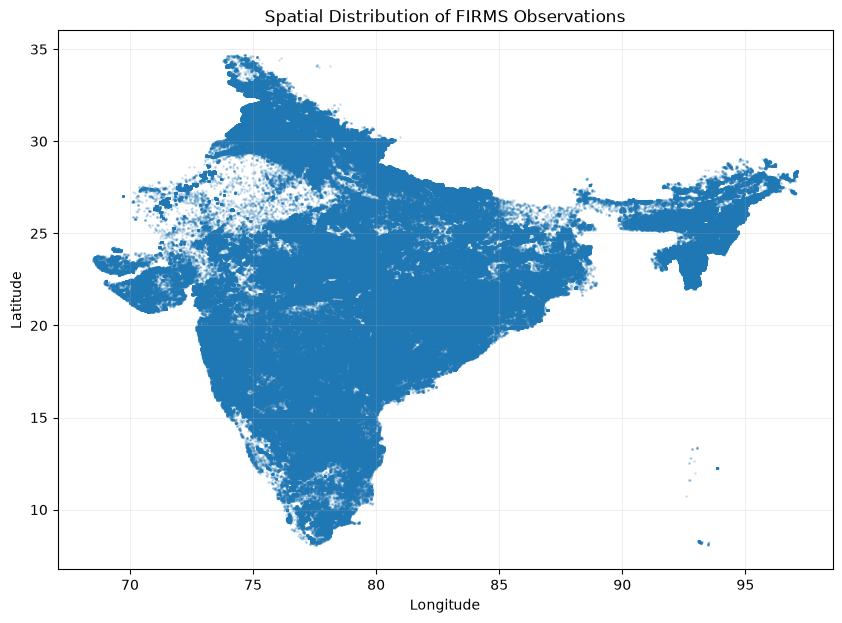

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    s=1,
    alpha=0.15
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of FIRMS Observations")
plt.grid(True, alpha=0.2)

plt.show()

In [60]:
# Distribution of spatially repeated locations

thresholds = [5, 10, 25, 50, 100, 500, 1000]

for threshold in thresholds:
    count = (grid_counts["observation_count"] >= threshold).sum()
    print(f"Grid cells with >= {threshold:4} observations: {count:,}")

Grid cells with >=    5 observations: 73,394
Grid cells with >=   10 observations: 9,591
Grid cells with >=   25 observations: 1,194
Grid cells with >=   50 observations: 801
Grid cells with >=  100 observations: 510
Grid cells with >=  500 observations: 132
Grid cells with >= 1000 observations: 45


In [61]:
# Top 50 most frequently observed spatial grid cells

top_grids = grid_counts.head(50).copy()

print(top_grids.to_string(index=False))

    grid_id  observation_count
 23.76_86.4               3812
23.78_86.39               3322
22.04_83.73               3056
21.92_83.35               2772
23.78_86.21               2733
20.97_85.17               2530
23.17_82.34               2334
23.69_87.12               2318
22.38_87.28               1977
 21.1_72.64               1955
22.04_83.74               1946
21.68_84.04               1900
21.08_85.04               1850
23.68_86.39               1809
20.79_85.26               1807
20.96_85.17               1746
21.77_84.02               1703
21.76_84.02               1661
23.56_87.24               1643
 22.79_86.2               1631
 23.68_86.4               1618
23.68_86.09               1600
23.69_86.39               1510
 22.37_87.3               1488
21.11_72.64               1400
23.72_86.44               1397
 23.77_86.4               1396
23.77_86.39               1395
21.11_72.65               1379
21.93_85.22               1295
 23.8_86.33               1260
22.04_83

In [62]:
# Top 50 most frequently observed spatial grid cells

top_grids = grid_counts.head(50).copy()

print(top_grids.to_string(index=False))

    grid_id  observation_count
 23.76_86.4               3812
23.78_86.39               3322
22.04_83.73               3056
21.92_83.35               2772
23.78_86.21               2733
20.97_85.17               2530
23.17_82.34               2334
23.69_87.12               2318
22.38_87.28               1977
 21.1_72.64               1955
22.04_83.74               1946
21.68_84.04               1900
21.08_85.04               1850
23.68_86.39               1809
20.79_85.26               1807
20.96_85.17               1746
21.77_84.02               1703
21.76_84.02               1661
23.56_87.24               1643
 22.79_86.2               1631
 23.68_86.4               1618
23.68_86.09               1600
23.69_86.39               1510
 22.37_87.3               1488
21.11_72.64               1400
23.72_86.44               1397
 23.77_86.4               1396
23.77_86.39               1395
21.11_72.65               1379
21.93_85.22               1295
 23.8_86.33               1260
22.04_83

In [63]:
# Calculate temporal activity for the top spatial grids

grid_persistence = (
    top_grid_observations
    .groupby("grid_id")
    .agg(
        observations=("grid_id", "size"),
        active_days=("acq_datetime", lambda x: x.dt.date.nunique()),
        first_detection=("acq_datetime", "min"),
        last_detection=("acq_datetime", "max")
    )
    .sort_values("observations", ascending=False)
)

grid_persistence.head(20)

NameError: name 'top_grid_observations' is not defined

In [64]:
# Select observations belonging to the top 50 spatial grid cells

top_grid_ids = set(top_grids["grid_id"])

top_grid_observations = df[df["grid_id"].isin(top_grid_ids)].copy()

print("Observations in top 50 grids:", len(top_grid_observations))
print("Unique top grids:", top_grid_observations["grid_id"].nunique())

Observations in top 50 grids: 80852
Unique top grids: 50


In [65]:
# Calculate temporal activity for the top spatial grids

grid_persistence = (
    top_grid_observations
    .groupby("grid_id")
    .agg(
        observations=("grid_id", "size"),
        active_days=("acq_datetime", lambda x: x.dt.date.nunique()),
        first_detection=("acq_datetime", "min"),
        last_detection=("acq_datetime", "max")
    )
    .sort_values("observations", ascending=False)
)

grid_persistence.head(20)

,observations,active_days,first_detection,last_detection
grid_id,,,,
23.76_86.4,3812,736,2023-09-15 07:29:00,2026-06-30 20:00:00
23.78_86.39,3322,717,2023-09-15 07:29:00,2026-06-30 20:00:00
22.04_83.73,3056,711,2023-09-16 19:39:00,2026-06-28 08:10:00
21.92_83.35,2772,726,2023-09-15 07:29:00,2026-06-30 20:01:00
23.78_86.21,2733,721,2023-09-16 07:10:00,2026-06-27 20:57:00
20.97_85.17,2530,688,2023-09-15 07:28:00,2026-06-29 07:51:00
23.17_82.34,2334,706,2023-09-23 20:47:00,2026-06-28 20:38:00
23.69_87.12,2318,663,2023-09-16 19:38:00,2026-06-28 20:38:00
22.38_87.28,1977,699,2023-09-16 19:38:00,2026-06-30 20:01:00


In [66]:
# Calculate activity span and activity ratio

grid_persistence["active_span_days"] = (
    grid_persistence["last_detection"]
    - grid_persistence["first_detection"]
).dt.days + 1

grid_persistence["activity_ratio"] = (
    grid_persistence["active_days"]
    / grid_persistence["active_span_days"]
)

grid_persistence.head(20)

,observations,active_days,first_detection,last_detection,active_span_days,activity_ratio
grid_id,,,,,,
23.76_86.4,3812,736,2023-09-15 07:29:00,2026-06-30 20:00:00,1020,0.721569
23.78_86.39,3322,717,2023-09-15 07:29:00,2026-06-30 20:00:00,1020,0.702941
22.04_83.73,3056,711,2023-09-16 19:39:00,2026-06-28 08:10:00,1016,0.699803
21.92_83.35,2772,726,2023-09-15 07:29:00,2026-06-30 20:01:00,1020,0.711765
23.78_86.21,2733,721,2023-09-16 07:10:00,2026-06-27 20:57:00,1016,0.709646
20.97_85.17,2530,688,2023-09-15 07:28:00,2026-06-29 07:51:00,1019,0.675172
23.17_82.34,2334,706,2023-09-23 20:47:00,2026-06-28 20:38:00,1009,0.699703
23.69_87.12,2318,663,2023-09-16 19:38:00,2026-06-28 20:38:00,1017,0.651917
22.38_87.28,1977,699,2023-09-16 19:38:00,2026-06-30 20:01:00,1019,0.685967


In [67]:
# Profile the top persistent spatial grids

persistent_profile = (
    top_grid_observations
    .groupby("grid_id")
    .agg(
        observations=("grid_id", "size"),
        active_days=("acq_datetime", lambda x: x.dt.date.nunique()),
        mean_frp=("frp", "mean"),
        max_frp=("frp", "max"),
        mean_brightness=("brightness", "mean"),
        high_confidence=("confidence", lambda x: (x == "h").mean() * 100),
        type_0_pct=("type", lambda x: (x == 0).mean() * 100),
        type_2_pct=("type", lambda x: (x == 2).mean() * 100),
        day_pct=("daynight", lambda x: (x == "D").mean() * 100)
    )
    .sort_values("active_days", ascending=False)
)

persistent_profile.head(20)

,observations,active_days,mean_frp,max_frp,mean_brightness,high_confidence,type_0_pct,type_2_pct,day_pct
grid_id,,,,,,,,,
21.1_72.64,1955,765,5.815161,41.76,330.317381,1.892583,0.818414,99.181586,37.442455
23.76_86.4,3812,736,3.084722,15.27,319.070622,0.052466,0.419727,99.580273,22.534103
21.11_72.65,1379,730,7.491777,55.27,332.503698,3.263234,0.145033,99.854967,42.059463
21.92_83.35,2772,726,3.325970,16.65,320.205960,0.036075,0.180375,99.819625,24.386724
23.78_86.21,2733,721,3.325342,19.52,320.164127,0.109769,0.475668,99.524332,26.198317
23.78_86.39,3322,717,3.335340,15.35,320.635801,0.000000,0.000000,100.000000,24.623721
22.04_83.73,3056,711,5.882186,52.27,331.920324,5.170157,2.388743,97.611257,34.489529
23.17_82.34,2334,706,3.159177,15.14,321.838603,0.128535,0.899743,99.100257,27.892031
22.38_87.28,1977,699,2.924643,12.51,318.169621,0.000000,1.669196,98.330804,22.711179


In [68]:
# Summary of the top recurrent locations

print("Top persistent grid summary")
print("=" * 50)

print("Number of grids analysed:", len(persistent_profile))
print("Mean active days:", round(persistent_profile["active_days"].mean(), 2))
print("Median active days:", round(persistent_profile["active_days"].median(), 2))
print("Mean FRP:", round(persistent_profile["mean_frp"].mean(), 2))
print("Mean type-2 percentage:", round(persistent_profile["type_2_pct"].mean(), 2))
print("Mean high-confidence percentage:", round(persistent_profile["high_confidence"].mean(), 2))

Top persistent grid summary
Number of grids analysed: 50
Mean active days: 610.34
Median active days: 622.0
Mean FRP: 2.9
Mean type-2 percentage: 98.09
Mean high-confidence percentage: 0.33


In [69]:
# Exploratory candidate persistent sources
# These are NOT confirmed industrial sources.

candidate_persistent_sources = grid_persistence[
    (grid_persistence["active_days"] >= 100) &
    (grid_persistence["activity_ratio"] >= 0.10)
].copy()

print("Candidate persistent grids:", len(candidate_persistent_sources))
print("\nTop candidates:")
print(candidate_persistent_sources.head(20))

Candidate persistent grids: 50

Top candidates:
             observations  active_days     first_detection  \
grid_id                                                      
23.76_86.4           3812          736 2023-09-15 07:29:00   
23.78_86.39          3322          717 2023-09-15 07:29:00   
22.04_83.73          3056          711 2023-09-16 19:39:00   
21.92_83.35          2772          726 2023-09-15 07:29:00   
23.78_86.21          2733          721 2023-09-16 07:10:00   
20.97_85.17          2530          688 2023-09-15 07:28:00   
23.17_82.34          2334          706 2023-09-23 20:47:00   
23.69_87.12          2318          663 2023-09-16 19:38:00   
22.38_87.28          1977          699 2023-09-16 19:38:00   
21.1_72.64           1955          765 2023-09-20 20:04:00   
22.04_83.74          1946          664 2023-09-16 19:39:00   
21.68_84.04          1900          679 2023-09-16 19:39:00   
21.08_85.04          1850          630 2023-09-17 19:20:00   
23.68_86.39          1

In [70]:
# Final label feasibility check

print("FIRMS type distribution:")
print(df["type"].value_counts().sort_index())

print("\nType distribution in top recurrent grids:")
print(
    top_grid_observations["type"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

FIRMS type distribution:
type
0    1523739
1         31
2     212854
3       2926
Name: count, dtype: int64

Type distribution in top recurrent grids:
type
0     1.18
2    98.32
3     0.51
Name: proportion, dtype: float64


In [71]:
# Create processed FIRMS dataset

processed_columns = [
    "latitude",
    "longitude",
    "brightness",
    "scan",
    "track",
    "acq_date",
    "acq_time",
    "acq_datetime",
    "satellite",
    "instrument",
    "confidence",
    "version",
    "bright_t31",
    "frp",
    "daynight",
    "type",
    "lat_grid",
    "lon_grid",
    "grid_id"
]

df_processed = df[processed_columns].copy()

OUTPUT_PATH = "../data/processed/firms_clean.csv"

df_processed.to_csv(OUTPUT_PATH, index=False)

print("Processed dataset saved successfully.")
print("Rows:", len(df_processed))
print("Columns:", len(df_processed.columns))
print("Path:", OUTPUT_PATH)

Processed dataset saved successfully.
Rows: 1739550
Columns: 19
Path: ../data/processed/firms_clean.csv


In [72]:
# Final FIRMS data analysis summary

print("=" * 60)
print("FIRMS DATA ANALYSIS — FINAL SUMMARY")
print("=" * 60)

print("\nDATASET")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Date range:", df["acq_date"].min(), "to", df["acq_date"].max())
print("Satellite:", ", ".join(df["satellite"].unique()))
print("Instrument:", ", ".join(df["instrument"].unique()))

print("\nQUALITY")
print("Missing cells:", df.isna().sum().sum())
print("Exact duplicates:", df.duplicated().sum())
print("Invalid latitude:", ((df["latitude"] < -90) | (df["latitude"] > 90)).sum())
print("Invalid longitude:", ((df["longitude"] < -180) | (df["longitude"] > 180)).sum())

print("\nSPATIAL")
print("Unique exact coordinate pairs:",
      df[["latitude", "longitude"]].drop_duplicates().shape[0])
print("Unique 0.01-degree grid cells:", df["grid_id"].nunique())
print("Grid cells with >=100 observations:",
      (grid_counts["observation_count"] >= 100).sum())
print("Grid cells with >=1000 observations:",
      (grid_counts["observation_count"] >= 1000).sum())

print("\nRECURRENCE")
print("Top grids analysed:", len(grid_persistence))
print("Mean active days:", round(grid_persistence["active_days"].mean(), 2))
print("Median active days:", round(grid_persistence["active_days"].median(), 2))

print("\nLABEL LIMITATIONS")
print("FIRMS type values are observations/categories, not validated industrial-fire ground truth.")
print("Industrial-fire labels require independent validation.")
print("Persistence identifies recurrent thermal activity, not industrial causality.")

FIRMS DATA ANALYSIS — FINAL SUMMARY

DATASET
Rows: 1739550
Columns: 22
Date range: 2023-09-15 to 2026-06-30
Satellite: SNPP
Instrument: SNPP

QUALITY
Missing cells: 0
Exact duplicates: 0
Invalid latitude: 0
Invalid longitude: 0

SPATIAL
Unique exact coordinate pairs: 1739195
Unique 0.01-degree grid cells: 644546
Grid cells with >=100 observations: 510
Grid cells with >=1000 observations: 45

RECURRENCE
Top grids analysed: 50
Mean active days: 610.34
Median active days: 622.0

LABEL LIMITATIONS
FIRMS type values are observations/categories, not validated industrial-fire ground truth.
Industrial-fire labels require independent validation.
Persistence identifies recurrent thermal activity, not industrial causality.


## Final Findings & ML Handoff

### Dataset
- Source: NASA FIRMS VIIRS 375m S-NPP standard archive
- Observations: 1,739,550
- Coverage: 2023-09-15 to 2026-06-30
- Satellite: SNPP
- Instrument: SNPP

### Data Quality
- Missing values: 0
- Exact duplicate rows: 0
- Invalid latitude: 0
- Invalid longitude: 0
- Invalid acquisition times: 0

### Spatial Analysis
- Unique exact coordinate pairs: 1,739,195
- Unique 0.01° spatial grid cells: 644,546
- Grid cells with ≥100 observations: 510
- Grid cells with ≥1000 observations: 45

### Recurrence
The highest-observation spatial grids show substantial temporal recurrence. 
The top recurrent locations were active across hundreds of days over approximately
1000-day observation spans.

Persistence/recurrent activity should be treated as evidence of recurring thermal
activity, not as proof of an industrial fire.

### Label / Ground-Truth Limitation
FIRMS `type` categories are observations/categories and are not validated
industrial-fire ground truth.

Type 2 dominates the recurrent spatial grids (~98.32%), making it potentially
useful as a weak proxy for persistent/static thermal-source analysis, but it
should not be treated as a confirmed industrial-fire label.

Independent validation is required for reliable industrial-fire classification.

### ML Handoff
Available features include:
- latitude / longitude
- brightness
- scan / track
- acquisition date/time
- confidence
- bright_t31
- FRP
- day/night
- FIRMS type
- spatial grid identifiers
- derived acquisition datetime

Important risks:
- repeated observations from the same physical source
- spatial leakage from nearby observations
- temporal leakage
- weak/non-independent labels

Therefore, random row-level train/test splitting may produce overly optimistic
evaluation. Grouped, spatial, or temporal validation should be considered.

### Processed Dataset
`data/processed/firms_clean.csv`

The raw FIRMS files remain unchanged under `data/raw/FIRMS/`.